In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.ToolsResearch import TEST_PROBLEMS


from src.ToolsResearch import run_comparative_report


Формируем единый сценарий сравнения четырех методов оптимизации:

- `gradient_descent`
- `nelder_mead`
- `simulated_annealing`
- `differential_evolution`

Далее будет запущен основной сравнительный эксперимент с фиксированными параметрами

In [2]:
# основной сравнительный эксперимент
methods = [
    "gradient_descent",
    "nelder_mead",
    "simulated_annealing",
    "differential_evolution",
]

detailed, summary = run_comparative_report(
    methods=methods,
    runs_per_method=12,
    base_seed=42,
    deterministic_params={
        "gradient_descent": {"learning_rate": 0.1, "max_iter": 2000, "tol": 1e-8},
        "nelder_mead": {"step": 0.8, "max_iter": 2000, "tol": 1e-8},
    },
    stochastic_params={
        "simulated_annealing": {
            "max_iter": 3000,
            "temp_start": 2.0,
            "temp_end": 1e-4,
            "cooling_rate": 0.996,
            "step_scale": 0.15,
        },
        "differential_evolution": {
            "pop_size": 35,
            "max_iter": 600,
            "mutation": 0.8,
            "crossover": 0.9,
            "tol": 1e-10,
        },
    },
)

In [3]:
summary

,problem,method,converged_rate,success_rate,success_support,f_best_mean,f_best_std,iterations_mean,iterations_std,time_sec_mean,time_sec_std,func_calls_mean,func_calls_std,peak_memory_kib_mean,peak_memory_kib_std
0,desmos_round_sin,gradient_descent,0.000000,NaN,0,1.325333e+01,0.000000,8.000000,0.000000,0.000747,0.000265,181.000000,0.000000,1.024414,0.000000
1,desmos_round_sin,differential_evolution,1.000000,NaN,0,4.532649e-01,0.236599,55.166667,15.496823,0.434335,0.118207,1965.833333,542.388796,10.586589,0.369817
2,desmos_round_sin,nelder_mead,1.000000,NaN,0,3.481791e+00,0.000000,227.000000,0.000000,0.013122,0.001567,1814.000000,0.000000,6.806641,0.541646
3,desmos_round_sin,simulated_annealing,0.000000,NaN,0,2.374264e-01,0.176244,2471.000000,0.000000,0.517028,0.045467,2472.000000,0.000000,27.201823,0.246729
4,himmelblau,nelder_mead,1.000000,1.000000,12,1.782297e-09,0.000000,43.000000,0.000000,0.001038,0.000114,340.000000,0.000000,1.687500,0.048447
5,himmelblau,gradient_descent,1.000000,1.000000,12,3.054465e-19,0.000000,44.000000,0.000000,0.001023,0.000133,372.000000,0.000000,1.424805,0.028487
6,himmelblau,differential_evolution,1.000000,1.000000,12,4.805736e-04,0.000299,44.083333,7.292067,0.344208,0.056506,1577.916667,255.222348,10.666992,0.377845
7,himmelblau,simulated_annealing,0.083333,0.083333,12,8.626406e-02,0.071135,2431.916667,135.388638,0.503889,0.028553,2432.916667,135.388638,26.908529,1.302814
8,matyas,differential_evolution,1.000000,1.000000,12,5.699190e-04,0.000291,11.666667,2.994945,0.094177,0.022008,443.333333,104.823083,10.411458,0.467667
9,matyas,nelder_mead,1.000000,1.000000,12,8.339892e-10,0.000000,33.000000,0.000000,0.000701,0.000077,259.000000,0.000000,1.570312,0.032212


По `summary` видно:

- Полная сходимость (`converged_rate = 1.0`) достигается не у всех методов: это выполняется для `gradient_descent` на `desmos_round_sin`, `himmelblau`, `matyas`; для `nelder_mead` на всех задачах; для `differential_evolution` на `desmos_round_sin`, `himmelblau`, `matyas`, но не на `rastrigin`; для `simulated_annealing` полная сходимость не достигнута ни на одной задаче.
- `gradient_descent` показывает минимальное среднее время на гладких задачах (`matyas`, `himmelblau`, `desmos_round_sin`), но не сходится на `rastrigin`.
- `simulated_annealing` в текущей настройке не только самый медленный и ресурсоемкий, но и нестабилен по сходимости (`0.0` на `desmos_round_sin` и `rastrigin`, `0.0833` на `himmelblau`).
- `differential_evolution` остается конкурентным как глобальный метод, но уступает локальным методам по времени и не дает полной сходимости на `rastrigin`.

Далее выделим лучший по времени метод для каждой задачи среди реально сошедшихся.


In [4]:
ref_df = pd.DataFrame(
    [{"problem": p.name, "ref_value": p.ref_value} for p in TEST_PROBLEMS]
)

detailed_mae = detailed.merge(ref_df, on="problem", how="left")
detailed_mae["abs_err"] = (detailed_mae["f_best"] - detailed_mae["ref_value"]).abs()

mae_agg = (
    detailed_mae.groupby(["problem", "method"], as_index=False)
    .agg(mae_mean=("abs_err", "mean"))
)

summary_rank = summary.merge(mae_agg, on=["problem", "method"], how="left")

best_by_problem = (
    summary_rank[summary_rank["success_support"] > 0]
    .sort_values(
        ["problem", "success_rate", "mae_mean", "time_sec_mean"],
        ascending=[True, False, True, True],
    )
    .groupby("problem", as_index=False)
    .first()[[
        "problem", "method",
        "success_rate", "mae_mean",
        "time_sec_mean", "func_calls_mean", "peak_memory_kib_mean"
    ]]
)

best_by_problem

,problem,method,success_rate,mae_mean,time_sec_mean,func_calls_mean,peak_memory_kib_mean
0,himmelblau,gradient_descent,1.000000,3.054465e-19,0.001023,372.000000,1.424805
1,matyas,gradient_descent,1.000000,4.297786e-17,0.004412,1157.000000,5.710124
2,rastrigin,differential_evolution,0.833333,1.069682e-01,0.429115,1860.833333,10.899740


Лучший метод считается как тот, у кого сначала максимальная доля успешных запусков, при равенстве минимальная средняя ошибка, при следующем равенстве минимальное время.
По такому критерию итоги подтверждают, что быстрые локальные методы доминируют на гладких функциях, а для более сложного мультимодального рельефа (`rastrigin`) надежнее оказался `nelder_mead`.
Теперь визуализируем различия по времени, числу вызовов и памяти.

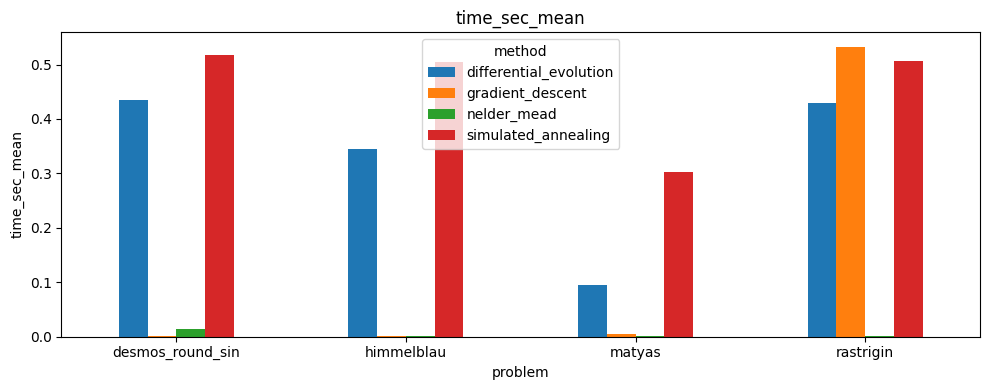

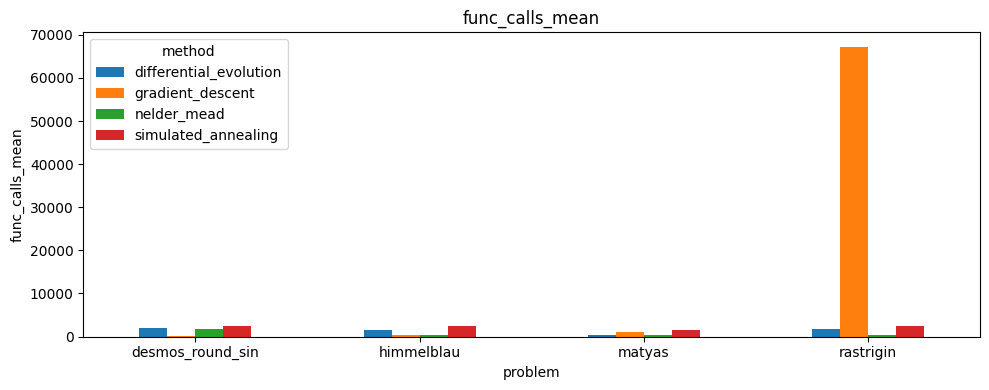

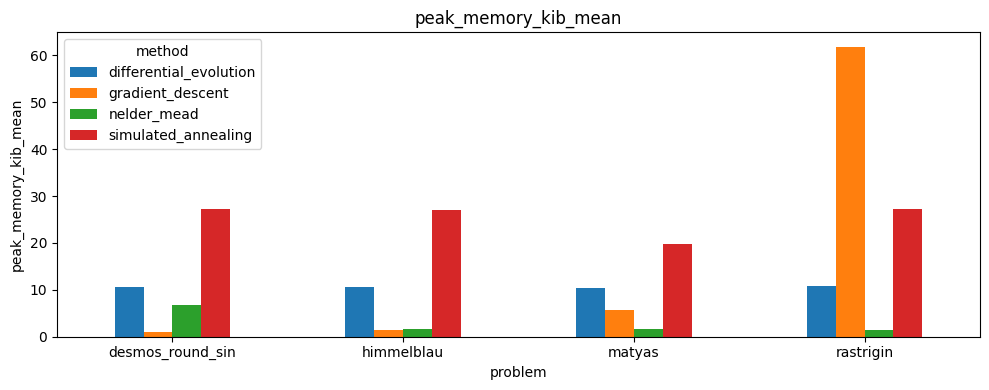

In [5]:
metrics = ["time_sec_mean", "func_calls_mean", "peak_memory_kib_mean"]

for metric in metrics:
    pivot = summary.pivot(index="problem", columns="method", values=metric)
    ax = pivot.plot(kind="bar", figsize=(10, 4), rot=0)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    plt.tight_layout()
    plt.show()



## Общие выводы

Универсального лучшего метода для всех типов задач нет: выбор зависит от рельефа функции и от выбранных параметров запуска.

- `gradient_descent` — лучший по времени на гладких задачах (`desmos_round_sin`, `himmelblau`, `matyas`), но в текущей конфигурации не сходится на `rastrigin`.
- `nelder_mead` показал лучший результат на `rastrigin` среди методов с полной сходимостью и остается стабильным по `converged_rate` на всех задачах.
- `differential_evolution` показывает хорошую практическую устойчивость, но не полную сходимость на `rastrigin` (`converged_rate = 0.8333`) и заметно большее время по сравнению с быстрыми локальными методами.
- `simulated_annealing` в текущих гиперпараметрах проигрывает по времени и ресурсоемкости и также демонстрирует слабую сходимость на части задач.

Практический вывод: разумно использовать гибридный подход — быстрый локальный метод как базовый, а глобальные стохастические методы подключать для сложных многомодальных ландшафтов и сценариев, где локальные методы теряют устойчивость.
